# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

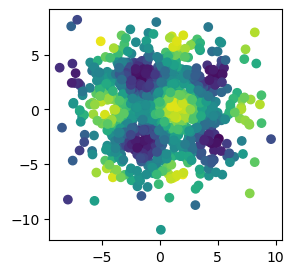

Iteration 0, Loss: 1.1175702810287476
Iteration 100, Loss: 1.0325826406478882
Iteration 200, Loss: 0.9799661636352539
Iteration 300, Loss: 0.8813453912734985
Iteration 400, Loss: 0.7413560152053833
Iteration 500, Loss: 0.6046716570854187
Iteration 600, Loss: 0.5086332559585571
Iteration 700, Loss: 0.4484423100948334
Iteration 800, Loss: 0.40618136525154114
Iteration 900, Loss: 0.366659015417099


/opt/anaconda3/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


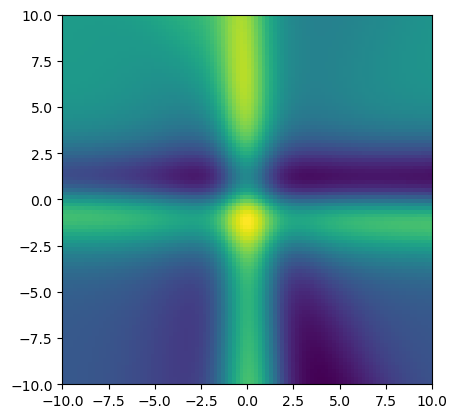

In [1]:
import data
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

import torch
model = torch.nn.Sequential(
    torch.nn.Linear(2,50), # x and y (50 is arbitrary)
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1) # our z
)

loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid(new_x, new_x), dim=2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [2]:
# Deep learning is a specific type of machine learning, which in and of itself is a type of artificial intelligence.
# Artificial intelligence is typically defined as a coomputer that is able to perform actions that normally require human intelligence.
# Machine Learning is a type of AI that can improve over time with minimal interference from humans.
# Deep Learning is a type of machine learning AI that learns from its mistakes through the use of artificial neural networks.

What is a neural network?

In [3]:
# An artificial neural network works by mimicking a human brain. 
# Essentially, it is like this field of nodes that each connect to one another.
# This allows for many different combinations that result in many different outputs for a given input.
# Each output is given a certain score, 
# and the neural network tries to optimize the overall score by testing different weights to different combinations.

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [4]:
# The 2 defines the number of variables for input, and the 50 is the number of layers.
# I looked at the actual documentation, and apparently it is actually some sort of linear transformation!

What does the activation function do?

In [5]:
# It allows us to model non linear relationships in data, such as the one we did in lecture.

What is a loss function? Why do we need one?

In [6]:
# The loss function tells the neural network how off it is from the expected results. 
# We need the loss function in order for our program to tell how much the neural network still needs to improve

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [7]:
# That way, our gradients reset every step of the way and we won't go in the wrong direction.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

Iteration 0, Loss: 1.1094253063201904
Iteration 100, Loss: 0.43178728222846985
Iteration 200, Loss: 0.2650247812271118
Iteration 300, Loss: 0.14317482709884644
Iteration 400, Loss: 0.09640089422464371
Iteration 500, Loss: 0.0654280036687851
Iteration 600, Loss: 0.04020809754729271
Iteration 700, Loss: 0.029464319348335266
Iteration 800, Loss: 0.024567078799009323
Iteration 900, Loss: 0.02208045870065689


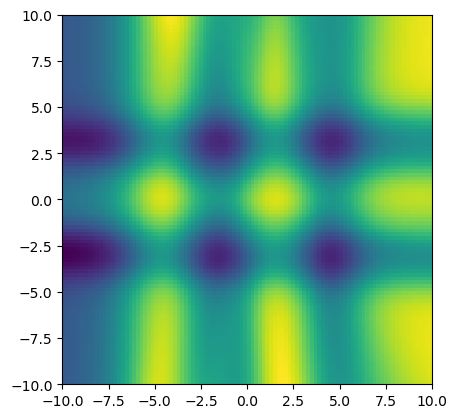

In [32]:
# Original
model = torch.nn.Sequential(
    torch.nn.Linear(2,50), 
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1) 
)
# Modified
#model = torch.nn.Sequential(
#    torch.nn.Linear(2,30), 
#    torch.nn.Sigmoid(),
#    torch.nn.Linear(30,1) 
#)

loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid(new_x, new_x, indexing='xy'), dim=2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [9]:
# The model with 30 neurons had a greater loss than the one with 50 neurons, showing how using more neurons tends to be better.

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [10]:
# Honestly, the ReLU function did not really do much. I ran it like 5 times, and 4 out of the 5 times it did slightly worse than Sigmoid.

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [11]:
# YOOOO the Tanh activation function is so much better. Like twice as good.

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [12]:
# Sigmoid and ReLU are pretty similar, while Tanh is a bit of an improvement.
# I actually searched it up because I was curious what the differences are, and apparently everyone agrees that
# ReLU is better than Sigmoid and Tanh, but for this specific model it looks like Tanh is better for some reason.

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [13]:
# Oh wow it did so much better. Lecture loss was like 0.26 while this one is 0.05. It's even better than the Tanh function.

Modify your model to have **two hidden layers** instead of one. Give that code here.

Iteration 0, Loss: 1.247554898262024
Iteration 100, Loss: 0.06366834044456482
Iteration 200, Loss: 0.03754317760467529
Iteration 300, Loss: 0.03179831802845001
Iteration 400, Loss: 0.02389802597463131
Iteration 500, Loss: 0.021861577406525612
Iteration 600, Loss: 0.020832424983382225
Iteration 700, Loss: 0.01819770224392414
Iteration 800, Loss: 0.016201429069042206
Iteration 900, Loss: 0.014092637225985527


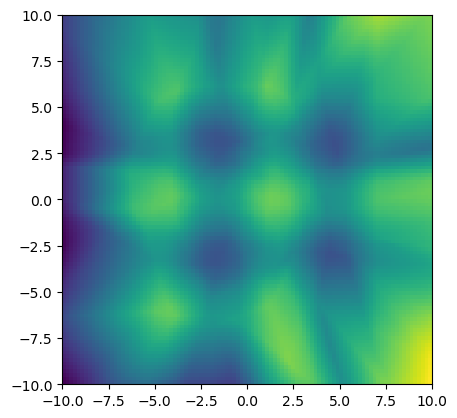

In [33]:
# I tampered with it a bit to make the loss function the lowest it could possibly be
model = torch.nn.Sequential(
    torch.nn.Linear(2,50), 
    torch.nn.ReLU(),
    torch.nn.Linear(50,50), 
    torch.nn.ReLU(),
    torch.nn.Linear(50,1) 
)

loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid(new_x, new_x, indexing='xy'), dim=2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [15]:
import new_data

Define a new model and train it **poorly** in the cell below.

In [42]:
model = torch.nn.Sequential(
    torch.nn.Linear(2,12),
    torch.nn.Sigmoid(),
    torch.nn.Linear(12,1) 
)

loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=100)

for t in range(1000):
    y_pred = model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid(new_x, new_x, indexing='xy'), dim=2)

output = model(grid).detach()

Iteration 0, Loss: 0.5381761789321899
Iteration 100, Loss: 6.135697364807129
Iteration 200, Loss: 0.4541298449039459
Iteration 300, Loss: 0.45280829071998596
Iteration 400, Loss: 0.45157507061958313
Iteration 500, Loss: 0.449300616979599
Iteration 600, Loss: 0.44824492931365967
Iteration 700, Loss: 0.44703859090805054
Iteration 800, Loss: 0.44396212697029114
Iteration 900, Loss: 0.44240602850914


Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

Iteration 0, Loss: 0.6214531660079956
Iteration 100, Loss: 0.11327297240495682
Iteration 200, Loss: 0.030096355825662613
Iteration 300, Loss: 0.018887126818299294
Iteration 400, Loss: 0.017019139602780342
Iteration 500, Loss: 0.015628701075911522
Iteration 600, Loss: 0.014914792962372303
Iteration 700, Loss: 0.014293140731751919
Iteration 800, Loss: 0.013844180852174759
Iteration 900, Loss: 0.013394756242632866


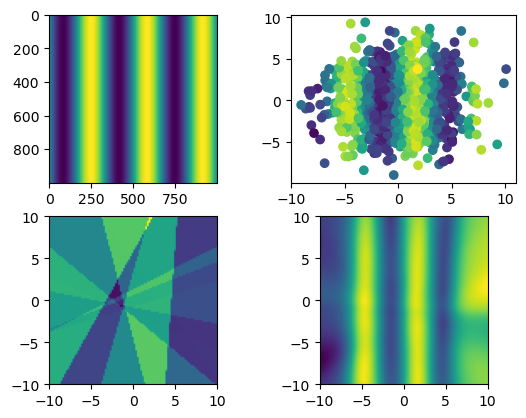

In [43]:
fig, axs = plt.subplots(2, 2)
axs[0,0].imshow(new_data.pattern)
axs[0,1].scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)
axs[1,0].imshow(output, extent = (-10, 10, -10, 10))


plt.imshow(output, extent = (-10, 10, -10, 10))

model = torch.nn.Sequential(
    torch.nn.Linear(2,50), 
    torch.nn.Tanh(),
    torch.nn.Linear(50,1) 
)

loss_fn = torch.nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for t in range(1000):
    y_pred = model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid(new_x, new_x, indexing='xy'), dim=2)

output = model(grid).detach()
axs[1,1].imshow(output, extent = (-10, 10, -10, 10))
plt.show()

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [ ]:
# Your code here

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!